# Leakage that survives cross-validation

Notebook 1 gave you cross-validation. This notebook shows what it does **not**
protect you from, because a tool you trust wrongly is more dangerous than no
tool at all.

Three things happen here, in increasing order of how much they should worry you.

1. A model built on **2,000 columns of pure random noise** scores 0.93 under
   cross-validation, measured by the
   area under the receiver operating characteristic (ROC) curve (AUC) of
   lesson 4. Nothing in the code is obviously wrong.
2. Fixing the obvious error improves it — but **not back to chance**, and the
   reason why is the most useful idea in this notebook.
3. A hyperparameter search over 25 combinations, on that same signal-free data,
   reports a score of 0.80. Nested cross-validation says 0.67.

By the end you will have the one rule that survives all of it.

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from methodology_data import load_fleet

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E7D8A", "#9C4221", "#F0BE50"
INK, SLATE = "#1A1A1A", "#4A5568"
plt.rcParams.update({
    "font.size": 11, "axes.edgecolor": SLATE, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": SLATE, "ytick.color": SLATE,
})

X, y = load_fleet(800)
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# A table with no information in it whatsoever. Every column is drawn from a
# standard normal, independently of the label and of every other column.
rng = np.random.default_rng(0)
noise = pd.DataFrame(rng.normal(size=(len(X), 2_000)),
                     columns=[f"n{i}" for i in range(2_000)], index=X.index)

print(f"{noise.shape[1]:,} columns of pure noise, {len(noise)} rows, "
      f"{int(y.sum())} positives")
print("the honest AUC of any model built on this data is 0.500")

2,000 columns of pure noise, 800 rows, 29 positives
the honest AUC of any model built on this data is 0.500


## 1. The catastrophe

Here is code that looks entirely reasonable, and is the single most common
serious error in applied machine learning.

*"2,000 features is too many, so let me keep the 10 most predictive ones, then
cross-validate a model on those."*

In [2]:
selector = SelectKBest(f_classif, k=10).fit(noise, y)      # <-- uses ALL the data
chosen = noise.loc[:, selector.get_support()]

leaky = cross_val_score(
    Pipeline([("scale", StandardScaler()),
              ("model", LogisticRegression(max_iter=2_000))]),
    chosen, y, cv=folds, scoring="roc_auc")

print(f"selected columns: {list(chosen.columns)}")
print(f"\ncross-validated AUC: {leaky.mean():.3f} +/- {leaky.std():.3f}")
print(f"fold by fold: {np.round(leaky, 3)}")
print(f"\nthe truth: 0.500")

selected columns: ['n231', 'n438', 'n551', 'n1057', 'n1097', 'n1211', 'n1448', 'n1491', 'n1705', 'n1915']

cross-validated AUC: 0.931 +/- 0.053
fold by fold: [0.928 0.979 0.975 0.943 0.832]

the truth: 0.500


**0.93 on data containing no information at all**, and four of the five folds
land between 0.93 and 0.98 — which is exactly what a trustworthy result looks
like.

The error is on the first line. `SelectKBest` was shown **every row**, including
the rows that would later serve as test folds. It searched 2,000 columns for the
ones that best matched the labels *it had already seen*, and handed those to
cross-validation. Every fold was then tested on rows whose labels had already
influenced which features existed.

**Cross-validation did not fail. It was lied to.** It faithfully measured a
procedure that had already peeked.

## 2. Doing it properly — and the surprise

The fix is to make selection part of the model, so it happens inside each fold,
on the training portion only. In scikit-learn that is one `Pipeline`.

In [3]:
honest = Pipeline([
    ("select", SelectKBest(f_classif, k=10)),     # now fitted per fold
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=2_000)),
])

scores = []
for seed in range(20):
    seeded = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    scores.append(cross_val_score(honest, noise, y, cv=seeded,
                                  scoring="roc_auc").mean())
scores = np.array(scores)

print(f"selection inside the fold, over 20 different CV seeds:")
print(f"  mean {scores.mean():.3f}   min {scores.min():.3f}   "
      f"max {scores.max():.3f}")
print(f"\nleaky version : 0.931")
print(f"honest version: {scores.mean():.3f}")
print(f"the truth     : 0.500")

selection inside the fold, over 20 different CV seeds:
  mean 0.658   min 0.576   max 0.759

leaky version : 0.931
honest version: 0.658
the truth     : 0.500


The leak is mostly gone — 0.93 down to about 0.66. **And it has not come back
to 0.5.** Twenty different fold seeds all agree that this signal-free dataset
supports a model better than chance.

This is not a bug in the code, and it is worth understanding properly.

**Why it happens.** With 2,000 columns and 800 rows, some columns correlate with
the label *by accident, across the whole dataset*. That accident is a property
of this particular sample — it is there in every subset of it, including every
training fold and every test fold. A selector fitted honestly on four fifths of
the data finds those columns, and they still "work" on the remaining fifth,
because the spurious correlation was never fold-specific in the first place.

**The consequence, which is the point of this notebook:**

> Cross-validation protects you from leaking *between folds*. It cannot protect
> you from having searched a large space of possibilities on a small sample. No
> rearrangement of the same 800 rows removes a pattern that is genuinely present
> in those 800 rows and absent from the world.

**What actually helps:** a test set held out before any of this began and used
exactly once; fewer candidates; or more rows. Nothing else.

## 3. Hyperparameter search is the same problem wearing a hat

Choosing between models is choosing, and choosing on data costs you the same
honesty. Search 25 combinations on the signal-free table and see what gets
reported.

In [4]:
grid = {"select__k": [2, 5, 10, 20, 40],
        "model__C": [0.01, 0.1, 1, 10, 100]}
inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

search = GridSearchCV(honest, grid, cv=inner, scoring="roc_auc").fit(noise, y)
candidate_scores = search.cv_results_["mean_test_score"]

print(f"best of {len(candidate_scores)} candidates : "
      f"{search.best_score_:.4f}   {search.best_params_}")
print(f"average candidate            : {candidate_scores.mean():.4f}")
print(f"worst candidate              : {candidate_scores.min():.4f}")

best of 25 candidates : 0.7999   {'model__C': 10, 'select__k': 20}
average candidate            : 0.7265
worst candidate              : 0.6840


The number a practitioner would report — `best_score_` — is the **maximum of 25
noisy estimates**. The maximum of a set of noisy numbers is biased upward even
when every one of them measures the same quantity, and here they nearly do.

The reported 0.80 is not the performance of the chosen configuration. It is the
performance of *whichever configuration got luckiest*.

## 4. Nested cross-validation

The fix is to treat the whole search — including the choosing — as the thing
being measured.

**Outer loop:** hold out a fifth of the data.
**Inner loop:** run the entire search on the remaining four fifths.
Then score the search's chosen model on the held-out fifth, which the search
never saw. Repeat five times.

The inner loop is allowed to overfit its own data as much as it likes; the outer
loop was never part of that.

In [5]:
outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)
nested = cross_val_score(
    GridSearchCV(honest, grid, cv=inner, scoring="roc_auc"),
    noise, y, cv=outer, scoring="roc_auc")

print(f"reported by the search : {search.best_score_:.4f}")
print(f"nested cross-validation: {nested.mean():.4f} +/- {nested.std():.4f}")
print(f"optimism of the search : {search.best_score_ - nested.mean():+.4f}")
print(f"\nfold by fold: {np.round(nested, 3)}")

reported by the search : 0.7999
nested cross-validation: 0.6699 +/- 0.1318
optimism of the search : +0.1300

fold by fold: [0.698 0.852 0.754 0.487 0.558]


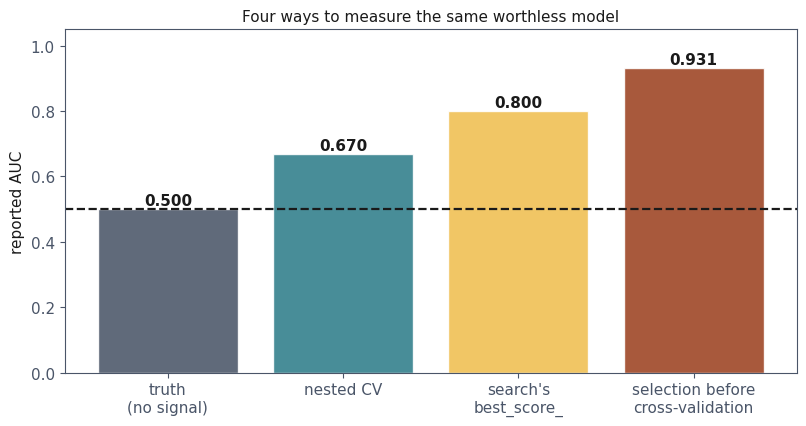

In [6]:
fig, ax = plt.subplots(figsize=(8.2, 4.4))
stages = ["truth\n(no signal)", "nested CV", "search's\nbest_score_",
          "selection before\ncross-validation"]
values = [0.5, nested.mean(), search.best_score_, leaky.mean()]
colours = [SLATE, TEAL, GOLD, RUST]

bars = ax.bar(stages, values, color=colours, alpha=.88, edgecolor="white")
ax.axhline(0.5, color=INK, ls="--", lw=1.6)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.012, f"{value:.3f}",
            ha="center", fontsize=11, fontweight="bold")

ax.set_ylim(0, 1.05)
ax.set_ylabel("reported AUC")
ax.set_title("Four ways to measure the same worthless model", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "leakage_ladder.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

Four numbers describing the *same data containing no signal*. Each step towards
the left is a piece of discipline, and each one costs you a chunk of the score
you would otherwise have reported.

Nobody in this picture wrote dishonest code. The difference between 0.93 and
0.50 is entirely a matter of **which choices were made while looking at which
data.**

## 5. Doing lesson 4's threshold honestly

Lesson 4 chose a decision threshold by sweeping it on the test set, and said at
the time that this was the wrong thing to do. Here is the right thing.

Split three ways: **train** to fit, **validation** to choose the threshold,
**test** to report — used once, at the end.

In [7]:
X_rest, X_test, y_rest, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_rest, y_rest, test_size=0.25, random_state=0, stratify=y_rest)

model = Pipeline([("scale", StandardScaler()),
                  ("model", LogisticRegression(max_iter=2_000))]).fit(X_train, y_train)

COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE = 140, 2_600


def total_cost(y_true, probability, threshold):
    flagged = probability >= threshold
    false_positive = int((flagged & (y_true == 0)).sum())
    false_negative = int((~flagged & (y_true == 1)).sum())
    return false_positive * COST_FALSE_POSITIVE + false_negative * COST_FALSE_NEGATIVE


candidates = np.linspace(0.01, 0.9, 200)
valid_probability = model.predict_proba(X_valid)[:, 1]
chosen_threshold = candidates[int(np.argmin(
    [total_cost(y_valid, valid_probability, t) for t in candidates]))]

test_probability = model.predict_proba(X_test)[:, 1]
print(f"threshold chosen on the validation set: {chosen_threshold:.3f}")
print(f"cost on the test set at that threshold: "
      f"{total_cost(y_test, test_probability, chosen_threshold):,} EUR")
print(f"cost on the test set at 0.50          : "
      f"{total_cost(y_test, test_probability, 0.5):,} EUR")

cheapest_on_test = candidates[int(np.argmin(
    [total_cost(y_test, test_probability, t) for t in candidates]))]
print(f"\nwhat we could have got by cheating: threshold {cheapest_on_test:.3f}, "
      f"cost {total_cost(y_test, test_probability, cheapest_on_test):,} EUR")
print("that last number is not reportable — it was chosen using the test set")

threshold chosen on the validation set: 0.050
cost on the test set at that threshold: 4,700 EUR
cost on the test set at 0.50          : 10,540 EUR

what we could have got by cheating: threshold 0.171, cost 3,300 EUR
that last number is not reportable — it was chosen using the test set


The honest threshold is worse on the test set than the cheating one. **It is
supposed to be.** The cheating number describes a threshold tuned to this
particular test set, and there is no reason it would hold on the next 200
drives; the honest number is an unbiased estimate of what happens next.

Note also that we now train on 56% of the data rather than 75%, because the
validation set has to come from somewhere. That is the real cost of doing this
properly on a small dataset — and it is why cross-validation exists.

## 6. Seeds, and what they do and do not buy

Everything in these three notebooks depended on a random seed. Fixing them is
the difference between a result someone else can reproduce and a story.

In [8]:
print("what to fix, and where:")
print("  train_test_split(..., random_state=0)")
print("  StratifiedKFold(..., shuffle=True, random_state=0)")
print("  LogisticRegression(..., random_state=0)   for solvers that sample")
print("  np.random.default_rng(0)                  for your own data generation")

# A fixed seed makes a run repeatable. It does not make the answer stable.
spread = []
for seed in range(30):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, random_state=seed, stratify=y)
    fitted = Pipeline([("scale", StandardScaler()),
                       ("model", LogisticRegression(max_iter=2_000))]).fit(X_tr, y_tr)
    spread.append(roc_auc_score(y_te, fitted.predict_proba(X_te)[:, 1]))

print(f"\n30 seeds, all of them 'reproducible':")
print(f"  worst {min(spread):.3f}   best {max(spread):.3f}   "
      f"spread {max(spread) - min(spread):.3f}")

what to fix, and where:
  train_test_split(..., random_state=0)
  StratifiedKFold(..., shuffle=True, random_state=0)
  LogisticRegression(..., random_state=0)   for solvers that sample
  np.random.default_rng(0)                  for your own data generation

30 seeds, all of them 'reproducible':
  worst 0.913   best 1.000   spread 0.087


**A fixed seed makes a number repeatable, not correct.** Every one of those 30
runs is perfectly reproducible by anyone with the same code, and they disagree
with each other by a wide margin.

So report the seed *and* the spread. One of those 30 seeds returns a perfect
1.000 — the same seed 3 that opened notebook 1. "AUC 1.000 (random_state=3)" is
fully reproducible and thoroughly misleading; "AUC 0.951 ± 0.019 over 5-fold
cross-validation, seed 0" is reproducible and honest.

Two habits worth adopting now, because the final project will be marked on them:

- **Fix every seed you can find, and write them down.** Anything you cannot fix
  — thread scheduling, GPU non-determinism — should be named in the report.
- **Record the versions.** `numpy`, `pandas` and `scikit-learn` change defaults
  between releases, and a result that cannot be reproduced two years later was
  not really reproducible.

## What to take away

- **Cross-validation measures a procedure.** If a step of your procedure saw
  the whole dataset, cross-validation will confirm your mistake with a small
  standard deviation.
- **Every preprocessing step belongs inside the `Pipeline`** — scaling,
  imputation, encoding, feature selection, resampling. Not before the split.
- **Fold-honest is not the same as honest.** Selecting 10 columns from 2,000 on
  800 rows still scored 0.66 on data with no signal, because the spurious
  correlations belong to the sample rather than to the split.
- **`best_score_` from a search is the maximum of many noisy estimates**, and is
  biased upward. Use **nested cross-validation** to measure the search itself.
- **Choose on validation data, report on test data, and touch the test set
  once.**
- **A fixed seed buys repeatability, not stability.** Report the seed and the
  spread.

### Homework

`Exercises/05_experimental_methodology.md`, due **Friday 30 October 2026**. It
gives you a dataset and a result that is too good, and asks you to find out why
— then to produce the honest number and say how much it cost.